In [1]:
import os
import os.path as op
from os.path import join
from os import makedirs

# pandas is a dataframe-managing library and it's the absolute coolest
import pandas as pd

# numpy is short for "numerical python" and it does math
import numpy as np

# nibabel handles nifti images
import nibabel as nib


# nilearn makes the best brain plots
# and their documentation/examples are so, so handy
# https://nilearn.github.io/stable/auto_examples/01_plotting/index.html
from nilearn import datasets
from nilearn.plotting.cm import _cmap_d as nilearn_cmaps
from nilearn.maskers import NiftiMasker
from nilearn.image import threshold_img, index_img
from nilearn.plotting import plot_stat_map
from nilearn.reporting import get_clusters_table

# matplotlib is the backbone of most python plotting
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

from neuromaps import transforms
from neuromaps.datasets import fetch_fslr

from nimare.decode.continuous import CorrelationDecoder
from nimare.transforms import p_to_z

from IPython.display import display
from surfplot import Plot


from gradec.fetcher import _fetch_features, _fetch_frequencies, _fetch_classification
from gradec.utils import _decoding_filter
from gradec.utils import _zero_medial_wall

from gradec.plot import plot_radar, plot_cloud

In [3]:
data_dir = "./dset"
deriv_dir = join(data_dir, "derivatives")
decoding_dir = "./decoding"

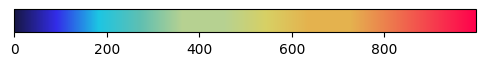

In [4]:
#CMAP = "Spectral_r"
# Define the number of colors in the colormap
num_colors = 1000

# Define anchor points for key colors using hex values
colors = [
    "#171744",  # Dark Blue
    "#322ce8",
    "#1cc5e3",  # light blue
    "#5fbfb1",
    "#b6d191",
    "#b6d191",
    "#d7d064",
    "#E4B24E",  # Yellow (adjusted)
    "#E4B24E",  # Yellow (adjusted)
    "#ed774d",  # Orange
    "#f63b4d",  # Orange
    "#ff004c",  # Red
]
# Create a smooth interpolation for the custom colormap
CMAP = LinearSegmentedColormap.from_list("custom_cmap", colors, N=num_colors)

# Plot the color gradient
plt.figure(figsize=(8, 2))
plt.imshow([list(range(num_colors))], aspect="auto", cmap=CMAP)
plt.gca().set_visible(False)
plt.colorbar(orientation="horizontal")
display(plt.gcf())
plt.close()

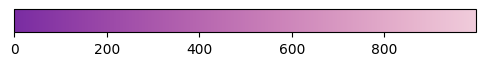

In [5]:
#atlas_cmap = "Spectral_r"
# Define the number of colors in the colormap
num_colors = 1000

# Define anchor points for key colors using hex values
colors = [
    "#792ca2",  
    "#9240a6",
    "#a755ab",
    "#ba6bb1",
    "#cb82b9",
    "#d99ac2",
    "#e6b3cd",
    "#f0ccdb",
]
# Create a smooth interpolation for the custom colormap
atlas_cmap = LinearSegmentedColormap.from_list("custom_cmap", colors, N=num_colors)

# Plot the color gradient
plt.figure(figsize=(8, 2))
plt.imshow([list(range(num_colors))], aspect="auto", cmap=atlas_cmap)
plt.gca().set_visible(False)
plt.colorbar(orientation="horizontal")
display(plt.gcf())
plt.close()

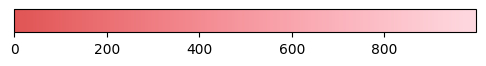

In [6]:
#roi_cmap = "Spectral_r"
# Define the number of colors in the colormap
num_colors = 1000

# Define anchor points for key colors using hex values
colors = [
    "#e05454",  
    "#e8686a",
    "#ee7b80",
    "#f48e95",
    "#f8a1a9",
    "#fbb4bd",
    "#fdc7cf",
    "#fed9e0",
]
# Create a smooth interpolation for the custom colormap
roi_cmap = LinearSegmentedColormap.from_list("custom_cmap", colors, N=num_colors)

# Plot the color gradient
plt.figure(figsize=(8, 2))
plt.imshow([list(range(num_colors))], aspect="auto", cmap=roi_cmap)
plt.gca().set_visible(False)
plt.colorbar(orientation="horizontal")
display(plt.gcf())
plt.close()

In [4]:
def trim_image(img=None, tol=1, fix=True):
    if fix:
        mask = img != tol
    else:
        mask = img <= tol
    if img.ndim == 3:
        mask = mask.any(2)
    mask0, mask1 = mask.any(0), mask.any(1)
    return img[np.ix_(mask1, mask0)]

In [5]:
def plot_vol(
    nii_img_thr, threshold, mask_contours=None, vmax=6, alpha=1, cmap=CMAP, dim=-0.45
):
    template = datasets.load_mni152_template(resolution=1)

    display_modes = ["x", "y", "z"]
    fig = plt.figure(figsize=(5, 5))
    fig.subplots_adjust(
        left=None, bottom=None, right=None, top=None, wspace=None, hspace=None
    )
    gs = GridSpec(2, 2, figure=fig)

    for dsp_i, display_mode in enumerate(display_modes):
        if display_mode == "z":
            ax = fig.add_subplot(gs[:, 1], aspect="equal")
            colorbar = True
        else:
            ax = fig.add_subplot(gs[dsp_i, 0], aspect="equal")
            colorbar = False

        display = plot_stat_map(
            nii_img_thr,
            bg_img=template,
            black_bg=False,
            draw_cross=False,
            annotate=True,
            alpha=alpha,
            cmap=cmap,
            threshold=threshold,
            colorbar=colorbar,
            display_mode=display_mode,
            cut_coords=1,
            vmax=vmax,
            axes=ax,
            dim=dim,  # Adjusted dimming factor
        )
        if mask_contours:
            display.add_contours(mask_contours, levels=[0.5], colors="black")

    return fig

In [6]:
def plot_surf(nii_img_thr, mask_contours=None, vmax=8, cmap=CMAP):
    map_lh, map_rh = transforms.mni152_to_fslr(nii_img_thr, fslr_density="32k")
    map_lh, map_rh = _zero_medial_wall(
        map_lh,
        map_rh,
        space="fsLR",
        density="32k",
    )
    # midthickness

    surfaces = fetch_fslr(density="32k")
    lh, rh = surfaces["inflated"]
    sulc_lh, sulc_rh = surfaces["sulc"]

    p = Plot(surf_lh=lh, surf_rh=rh, layout="grid")
    p.add_layer({"left": sulc_lh, "right": sulc_rh}, cmap="binary_r", cbar=False)
    p.add_layer(
        {"left": map_lh, "right": map_rh},
        cmap=cmap,
        cbar=False,
        color_range=(-vmax, vmax),
    )
    if mask_contours:
        mask_lh, mask_rh = transforms.mni152_to_fslr(mask_contours, fslr_density="32k")
        mask_lh, mask_rh = _zero_medial_wall(
            mask_lh,
            mask_rh,
            space="fsLR",
            density="32k",
        )
        mask_arr_lh = mask_lh.agg_data()
        mask_arr_rh = mask_rh.agg_data()
        countours_lh = np.zeros_like(mask_arr_lh)
        countours_lh[mask_arr_lh != 0] = 1
        countours_rh = np.zeros_like(mask_arr_rh)
        countours_rh[mask_arr_rh != 0] = 1

        colors = [(0, 0, 0, 0)]
        contour_cmap = ListedColormap(colors, "regions", N=1)
        line_cmap = ListedColormap(["black"], "regions", N=1)
        p.add_layer(
            {"left": countours_lh, "right": countours_rh},
            cmap=line_cmap,
            as_outline=True,
            cbar=False,
        )
        p.add_layer(
            {"left": countours_lh, "right": countours_rh},
            cmap=contour_cmap,
            cbar=False,
        )

    return p.build()

In [7]:
DSET, MODEL = "neuroquery", "lda"
decoder_fn = op.join(data_dir, f"{MODEL}_{DSET}_decoder.pkl.gz")

decoder = CorrelationDecoder.load(decoder_fn)

features = _fetch_features(DSET, MODEL, data_dir=decoding_dir)
frequencies = _fetch_frequencies(DSET, MODEL, data_dir=decoding_dir)
classification, class_lst = _fetch_classification(DSET, MODEL, data_dir=decoding_dir)

In [8]:
mask_img = datasets.load_mni152_brain_mask(resolution=1)
masker = NiftiMasker(mask_img=mask_img)
masker = masker.fit()

In [9]:
test_dict = {
    "1s": "Group Average (One-Sample T-Test)",
    "2s": "Group Comparison (Two-Sample Unpaired T-Test: ASD-TD)",
}

/var/folders/x1/rzvtxb3x273_5fvyk8ftl70r0000gn/T/ipykernel_48547/138938451.py:31: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  cluster_df = pd.read_table(cluster_fn, skiprows=8, delim_whitespace=True, names=column_names)
/Users/chloehampson/Desktop/habenula-comparison/.venv/lib/python3.9/site-packages/nilearn/maskers/nifti_masker.py:108: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(


Cluster correction table:
     pthr  .10000  .05000  .02000  .01000
0  0.0500  1457.0  1766.0  2186.0  2473.5
1  0.0200   505.9   615.3   757.0   870.0
2  0.0100   276.9   335.6   416.5   479.0
3  0.0050   164.7   200.0   250.0   293.0
4  0.0020    91.1   111.7   139.7   163.0
5  0.0010    61.3    75.5    93.8   111.4
6  0.0005    42.4    51.9    66.3    77.8
7  0.0002    26.5    33.0    43.7    50.5
8  0.0001    18.7    23.9    31.4    37.5
Total subjects: 1480, Group sizes: 661, 819

=== Processing Group Average (One-Sample T-Test) ===
File ./dset/derivatives/hb-conn/group-drawn/habenula/averaged/sub-group_task-rest_desc-1SampletTest.nii.gz already exists, skipping conversion.
Cluster extent: 37.5, p-threshold: 0.0001, z-threshold: 3.890591886413094


/Users/chloehampson/Desktop/habenula-comparison/.venv/lib/python3.9/site-packages/nilearn/maskers/nifti_masker.py:108: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(


Significant clusters:
   Cluster ID     X     Y     Z  Peak Stat Cluster Size (mm3)
0           1   3.5 -24.5   3.5  28.048861             480872
1          1a   3.5  -0.5   3.5  15.181170                   
2          1b  15.5 -30.5  -4.5  13.453623                   
3          1c   5.5   7.5  -0.5  12.664586                   
4           2 -22.5  -0.5  69.5   6.631356               1728
5          2a -14.5  -0.5  71.5   4.605451                   
6           3 -40.5  33.5  11.5   6.021825               3192
7          3a -38.5  19.5  23.5   5.315705                   
8          3b -46.5  23.5  19.5   5.018819                   
9          3c -46.5  21.5  29.5   4.779835                   
10          4  43.5 -14.5 -28.5   5.956895                488
11          5 -32.5 -56.5  45.5   5.669044               1144
12         5a -26.5 -64.5  41.5   4.614406                   
13          6  37.5 -18.5  39.5   5.620476               1048
14         6a  49.5 -14.5  45.5   5.378482      

/Users/chloehampson/Desktop/habenula-comparison/.venv/lib/python3.9/site-packages/nilearn/maskers/nifti_masker.py:108: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(


...

Significant clusters:
  Cluster ID     X     Y     Z  Peak Stat Cluster Size (mm3)
0          1  63.5 -38.5  -0.5   5.405111                816
1         1a  59.5 -30.5   5.5   4.043229                   
2          2 -54.5 -20.5  -6.5   5.140213               1640
3         2a -60.5 -28.5   3.5   4.647803                   
4         2b -56.5  -8.5 -12.5   4.571720                   
5         2c -60.5 -30.5  -4.5   4.434737                   
6          3  47.5 -40.5   3.5   4.957223                424
7          4 -62.5 -14.5  41.5   4.905821                312
8          5 -56.5 -56.5  21.5   4.551557                376
Saved thresholded nifti: ./dset/derivatives/hb-conn/group-atlas/habenula/difference/sub-group_task-rest_desc-2SampletTest_thresh.nii.gz
Generating visualizations...


/Users/chloehampson/Desktop/habenula-comparison/.venv/lib/python3.9/site-packages/nilearn/maskers/nifti_masker.py:108: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(


Successfully exported FILTERED decoding metrics to: ./dset/derivatives/hb-conn/decoding_results/2s_atlas_neuroquery_filtered_terms.csv


/Users/chloehampson/Desktop/habenula-comparison/.venv/lib/python3.9/site-packages/gradec/plot.py:81: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"projection": "polar"})
/Users/chloehampson/Desktop/habenula-comparison/.venv/lib/python3.9/site-packages/gradec/plot.py:157: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(width, height))


Saved figures to ./dset/derivatives/hb-conn/group-atlas/habenula/difference


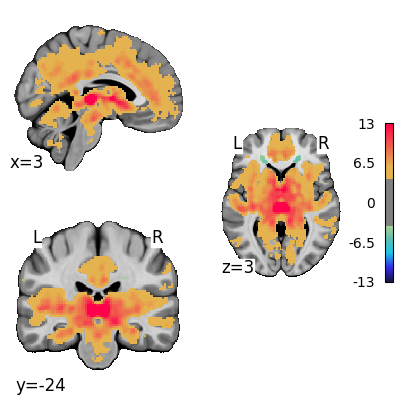

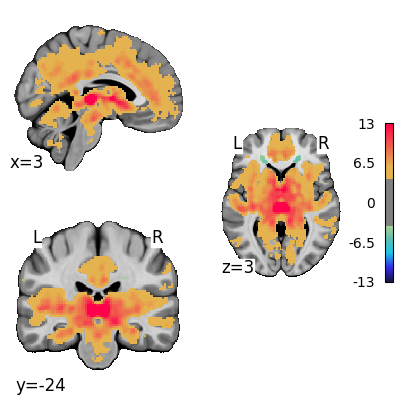

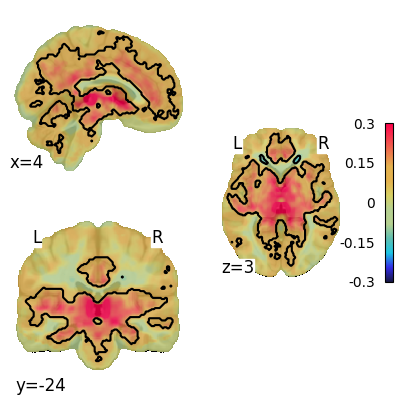

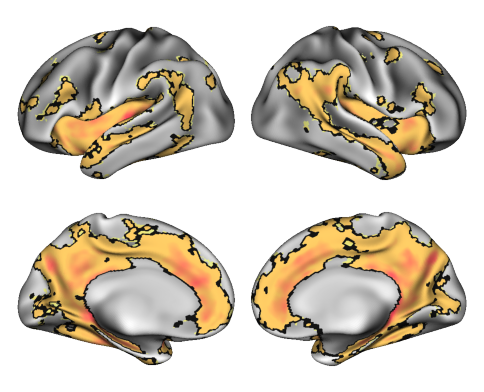

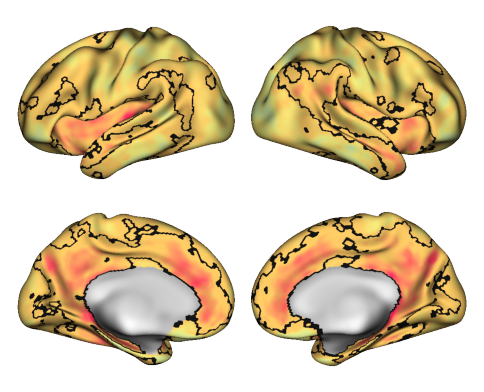

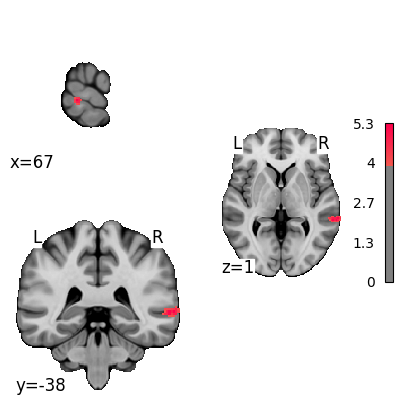

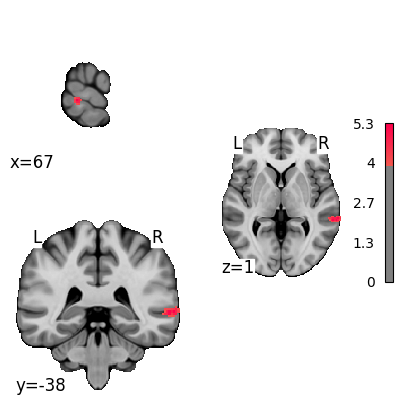

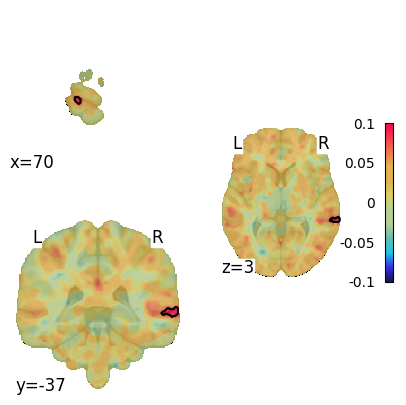

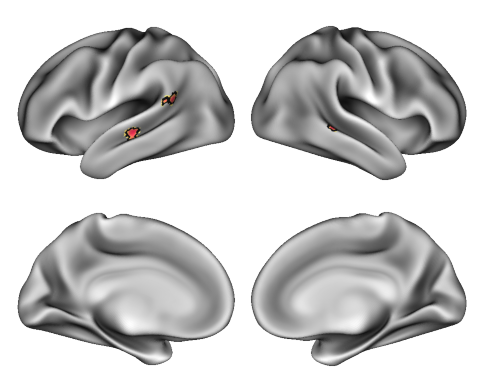

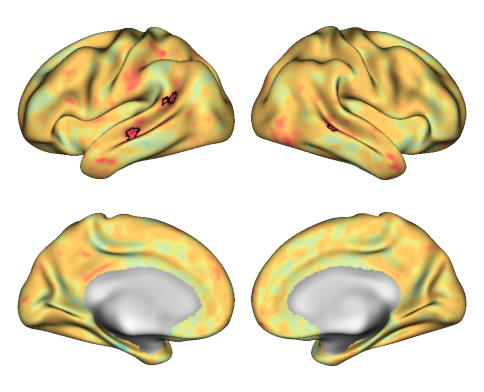

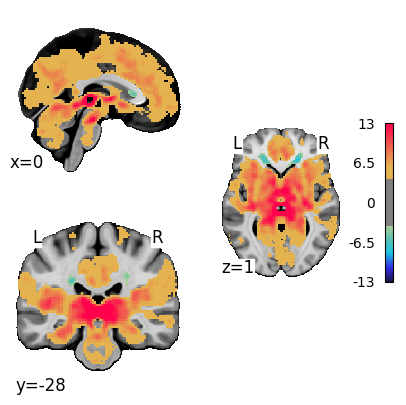

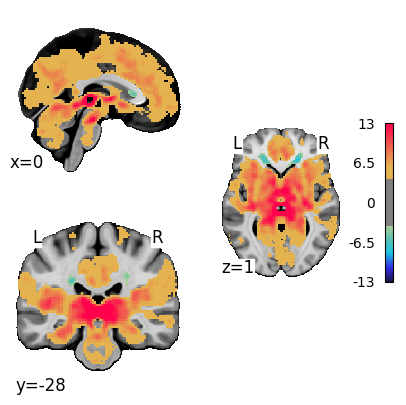

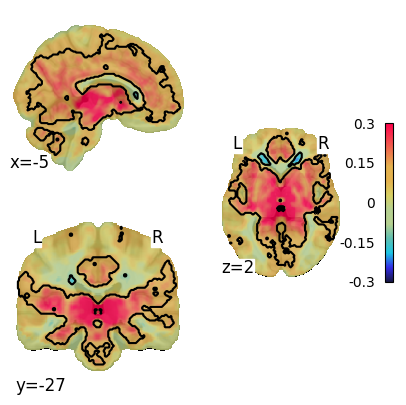

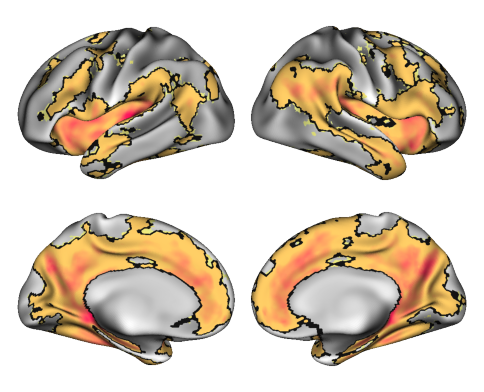

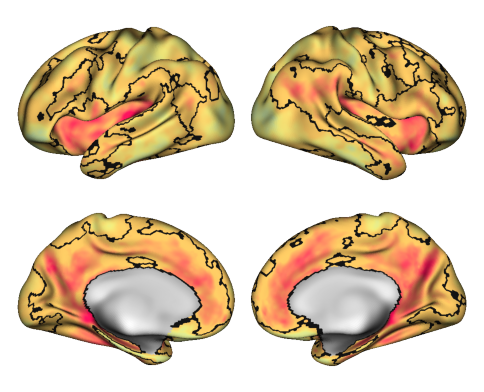

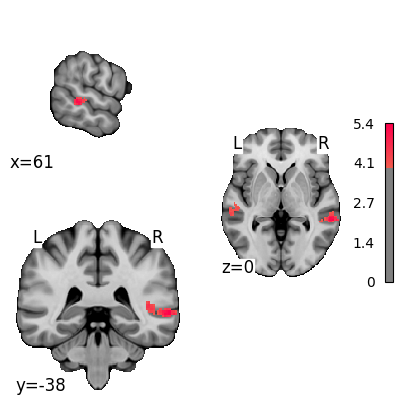

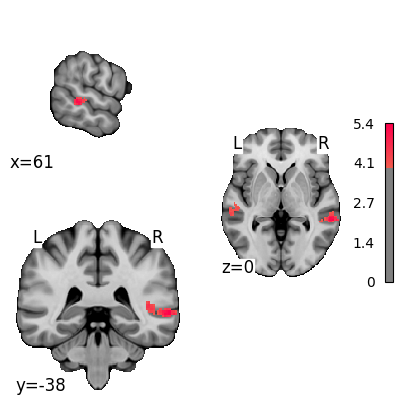

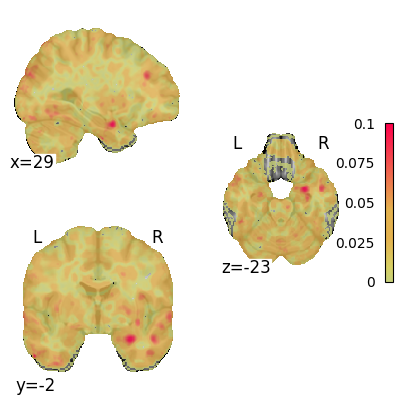

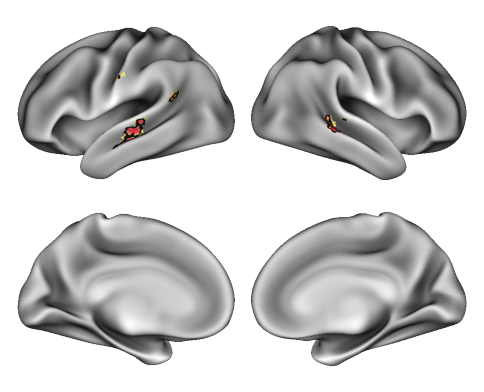

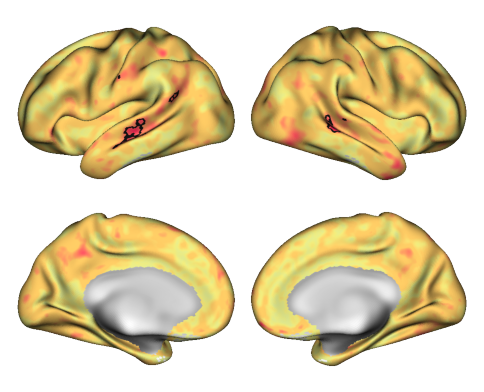

In [10]:
# Setup directories and file paths
group_drawn_dir = op.join(deriv_dir, "hb-conn/group-drawn/habenula")
group_atlas_dir = op.join(deriv_dir, "hb-conn/group-atlas/habenula")

group_dirs = [group_drawn_dir, group_atlas_dir]

for group_dir in group_dirs:
    group_avg_dir = op.join(group_dir, "averaged")
    group_diff_dir = op.join(group_dir, "difference")

    makedirs(group_avg_dir, exist_ok=True)
    makedirs(group_diff_dir, exist_ok=True)

    # File paths
    brik_fn = op.join(
        group_dir, "sub-group_task-rest_desc-1S2StTesthabenula_briks+tlrc.BRIK"
    )
    table_fn = op.join(group_dir, "sub-group_task-rest_desc-1S2StTesthabenula_table.txt")
    cluster_fn = op.join(
        group_dir, "clustsim", "clustsim_out.NN2_2sided.1D"
    )
    nii_1s_fn = op.join(
        group_avg_dir, "sub-group_task-rest_desc-1SampletTest.nii.gz"
    )
    nii_2s_fn = op.join(
        group_diff_dir, "sub-group_task-rest_desc-2SampletTest.nii.gz"
    )

    # Load cluster correction table
    column_names = [".10000", ".05000", ".02000", ".01000"]
    cluster_df = pd.read_table(cluster_fn, skiprows=8, delim_whitespace=True, names=column_names)
    cluster_df = cluster_df.reset_index()
    cluster_df.rename(columns={'index': 'pthr'}, inplace=True)
    print("Cluster correction table:")
    print(cluster_df)

    # Analysis parameters
    brik_idx = [8, 10]
    nii_fns = [nii_1s_fn, nii_2s_fn]
    tests = ["1s", "2s"]
    alpha = ".01000"
    pthrs = [0.0001, 0.0001]
    cohen_thresh = 0

    # Load participant data for effect size calculations
    data_df = pd.read_csv(table_fn, sep="\t")
    n_sub = data_df.groupby("group").size().sum()
    n_sub_1, n_sub_2 = data_df.groupby("group").size().values
    print(f"Total subjects: {n_sub}, Group sizes: {n_sub_1}, {n_sub_2}")

    # Process each test type (1-sample and 2-sample)
    for brik_i, nii_fn, test, pthr in zip(brik_idx, nii_fns, tests, pthrs):
        print(f"\n=== Processing {test_dict[test]} ===")
        
        # Check if the output file already exists
        if not os.path.exists(nii_fn):
            # determine which group we're processing by the parent directory name
            parent_base = op.basename(op.dirname(group_dir))
            if parent_base == "group-drawn":
                print(f"Creating {nii_fn} from drawn group...")
                convert = f"3dAFNItoNIFTI -prefix {nii_fn} {brik_fn}[{brik_i}]"
                os.system(convert)
            elif parent_base == "group-atlas":
                print(f"Creating {nii_fn} for group-atlas...")
                if test == "1s":
                    convert = f"3dAFNItoNIFTI -prefix {nii_fn} {brik_fn}[{brik_i}]"
                    os.system(convert)
                elif test == "2s":
                    # create an absolute-valued difference map on disk
                    convert = f"3dcalc -a {brik_fn}'[{brik_i}]' -expr 'abs(a)' -prefix {nii_fn}"
                    os.system(convert)
            else:
                raise RuntimeError(f"Unexpected group directory parent: {parent_base}")
        else:
            print(f"File {nii_fn} already exists, skipping conversion.")
        
        # Load and threshold images
        nii_img = nib.load(nii_fn)

        # For two-sample (group-difference) maps, ensure values are positive
        # by taking the absolute value if necessary. This is a safety net
        # but the on-disk nifti should already be absolute from the 3dcalc above.
        if test == "2s":
            try:
                nii_arr_raw = masker.transform(nii_img)
                if np.nanmax(nii_arr_raw) <= 0:
                    # all non-positive -> take absolute
                    nii_arr_pos = np.abs(nii_arr_raw)
                    nii_img = masker.inverse_transform(nii_arr_pos)
            except Exception:
                img = nib.load(nii_fn)
                data = img.get_fdata()
                if np.nanmax(data) <= 0:
                    img_pos = nib.Nifti1Image(np.abs(data), img.affine, img.header)
                    nii_img = img_pos

        z_thresh = p_to_z(pthr)
        clust_ext = cluster_df.loc[cluster_df["pthr"] == pthr, alpha].values[0]
        nii_thr_img = threshold_img(nii_img, z_thresh, cluster_threshold=clust_ext)
        print(f"Cluster extent: {clust_ext}, p-threshold: {pthr}, z-threshold: {z_thresh}")
        
        # Calculate effect sizes (Cohen's d)
        nii_arr = masker.transform(nii_img)
        if test == "1s":
            nii_cohen_arr = nii_arr / np.sqrt(n_sub)
        elif test == "2s":
            nii_cohen_arr = nii_arr / (np.sqrt(n_sub_1) + np.sqrt(n_sub_2))
        
        nii_cohen_img = masker.inverse_transform(nii_cohen_arr)
        
        # Create contour masks for visualization
        nii_thr_arr = masker.transform(nii_thr_img)
        nii_contour_arr = np.zeros_like(nii_thr_arr)
        nii_contour_arr[(nii_thr_arr > z_thresh) | (nii_thr_arr < -z_thresh)] = 1
        nii_contour_img = masker.inverse_transform(nii_contour_arr)
        nii_contour_img_3d = index_img(nii_contour_img, 0)
        
        # Set visualization parameters
        vmax = round(np.max(np.abs(nii_thr_arr)), 2)
        vmax = 13 if vmax > 13 else vmax
        c_vmax = 0.1 if test == "2s" else 0.3
        
        # Generate cluster table and save thresholded images
        clusters = get_clusters_table(
            nii_thr_img, z_thresh, two_sided=True
        )
        print("Significant clusters:")
        print(clusters)
        
        # Save thresholded images to appropriate directories
        if test == "1s":
            thresh_fn = op.join(group_avg_dir, f"sub-group_task-rest_desc-1SampletTest_thresh.nii.gz")
        elif test == "2s":
            thresh_fn = op.join(group_diff_dir, f"sub-group_task-rest_desc-2SampletTest_thresh.nii.gz")
        
        nib.save(nii_thr_img, thresh_fn)
        print(f"Saved thresholded nifti: {thresh_fn}")
        
        # Generate all visualizations
        print("Generating visualizations...")
        
        # First, get coordinates from the thresholded statistical map
        from nilearn.plotting import find_xyz_cut_coords
        coords = find_xyz_cut_coords(nii_thr_img, activation_threshold=z_thresh)
        
        stat_fig = plot_vol(nii_thr_img, z_thresh, vmax=vmax, cmap=CMAP)
        vol_fig = plot_vol(nii_thr_img, z_thresh, vmax=vmax, cmap=CMAP)
        #vol_multi_fig = plot_vol_multi(nii_thr_img, z_thresh, [(-53,-52,18), (47, -39, 3), (1, -38, -1), (2, -27, -1)], vmax=vmax, cmap=CMAP)
        cohen_fig = plot_vol(
            nii_cohen_img,
            cohen_thresh,
            mask_contours=nii_contour_img_3d,
            vmax=c_vmax,
            alpha=0.8,
            cmap=CMAP,
        )
        surf_fig = plot_surf(nii_thr_img, mask_contours=nii_contour_img_3d, vmax=vmax, cmap=CMAP)
        cohen_surf_fig = plot_surf(
            nii_cohen_img, mask_contours=nii_contour_img_3d, vmax=c_vmax, cmap=CMAP
        )
        
        # Prepare data for decoding — use absolute values for 2-sample maps
        if test == "1s":
            nii_pos_arr = np.where(nii_arr > 0, nii_arr, 0)
            img_to_decode = masker.inverse_transform(nii_pos_arr)
        elif test == "2s":
            nii_abs_arr = np.abs(nii_arr)
            nii_pos_arr = np.where(nii_abs_arr > 0, nii_abs_arr, 0)
            img_to_decode = masker.inverse_transform(nii_pos_arr)
        
        # Decode the image
        corrs_df = decoder.transform(img_to_decode)

        roi_type = "drawn" if "group-drawn" in group_dir else "atlas"
        
        # Define a target directory for your data outputs (creates it if it doesn't exist)
        decoding_output_dir = op.join(deriv_dir, "hb-conn", "decoding_results")
        os.makedirs(decoding_output_dir, exist_ok=True)
        
        # Create a descriptive, unique filename 
        # e.g., '1s_drawn_neuroquery_terms.csv'
        csv_filename = op.join(decoding_output_dir, f"{test}_{roi_type}_neuroquery_terms.csv")
        
        # # Deep copy the data frame and make sure the text index is a clean column named 'Term'
        # export_df = corrs_df.copy()
        # export_df.index.name = 'Term'
        # export_df = export_df.reset_index()
        
        # # Save out to disk
        # export_df.to_csv(csv_filename, index=False)
        # print(f"Successfully exported unedited decoding metrics to: {csv_filename}")
        
        num_val = [int(lab.split("__")[1].split("_")[0]) for lab in corrs_df.index.to_list()]
        indices = np.argsort(num_val)
        corrs_df = corrs_df.iloc[indices]
        filtered_df, filtered_features, filtered_frequencies = _decoding_filter(
            corrs_df,
            features,
            classification,
            freq_by_topic=frequencies,
            class_by_topic=class_lst,
        )

        csv_filename = op.join(decoding_output_dir, f"{test}_{roi_type}_neuroquery_filtered_terms.csv")
        
        export_df = filtered_df.copy()
        # Clean/Reset the index to make 'Term' an explicit column if it isn't already
        if export_df.index.name != 'Term' and 'Term' not in export_df.columns:
            export_df.index.name = 'Term'
            export_df = export_df.reset_index()
            
        export_df.to_csv(csv_filename, index=False)
        print(f"Successfully exported FILTERED decoding metrics to: {csv_filename}")
        
        # Visualize decoding results
        corrs = filtered_df["r"].to_numpy()
        
        # Save figures to appropriate directories
        if test == "1s":
            fig_save_dir = group_avg_dir
        elif test == "2s":
            fig_save_dir = group_diff_dir
        
        # Radar plot
        plot_radar(
            corrs,
            filtered_features,
            MODEL,
            cmap=CMAP,
            out_fig=op.join(fig_save_dir, f"{test}_radar.png"),
        )
        
        # Word cloud plot
        plot_cloud(
            corrs,
            filtered_features,
            MODEL,
            width=10,
            height=5,
            frequencies=filtered_frequencies,
            cmap=CMAP,
            out_fig=op.join(fig_save_dir, f"{test}_wordcloud.png"),
        )
        
        vol_fig.savefig(op.join(fig_save_dir, f"{test}_volume.png"), bbox_inches="tight", dpi=300)
        #vol_multi_fig.savefig(op.join(fig_save_dir, f"{test}_volume-multi.png"), bbox_inches="tight", dpi=300)
        cohen_fig.savefig(op.join(fig_save_dir, f"{test}_volume-cohen.png"), bbox_inches="tight", dpi=300)
        surf_fig.savefig(op.join(fig_save_dir, f"{test}_surface.png"), bbox_inches="tight", dpi=300)
        cohen_surf_fig.savefig(op.join(fig_save_dir, f"{test}_surface-cohen.png"), bbox_inches="tight", dpi=300)
        
        print(f"Saved figures to {fig_save_dir}")
        print("="*50)

Saved combined figure: ./dset/derivatives/hb-conn/group-drawn/habenula/averaged/combined_1s.png


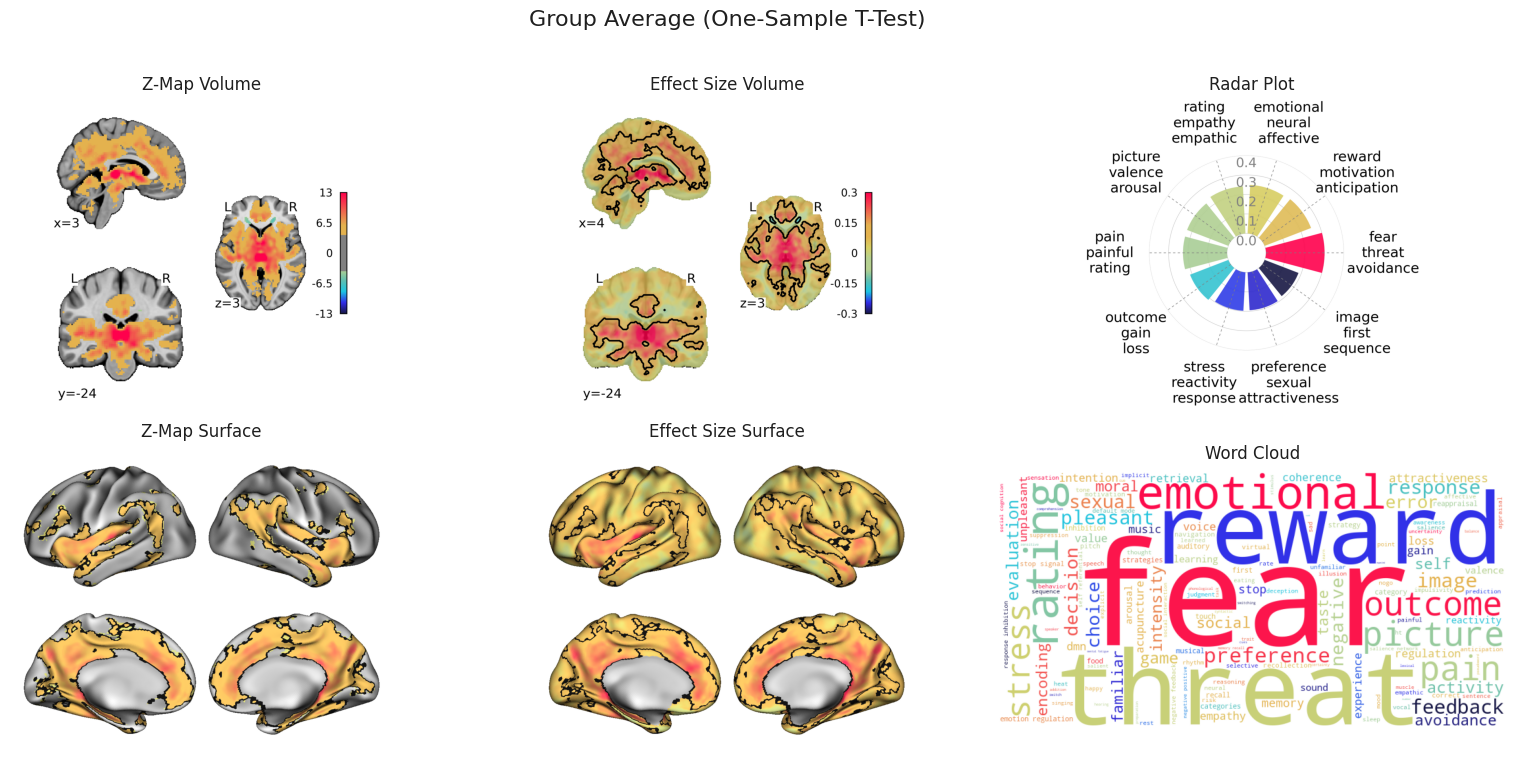

Saved combined figure: ./dset/derivatives/hb-conn/group-drawn/habenula/difference/combined_2s.png


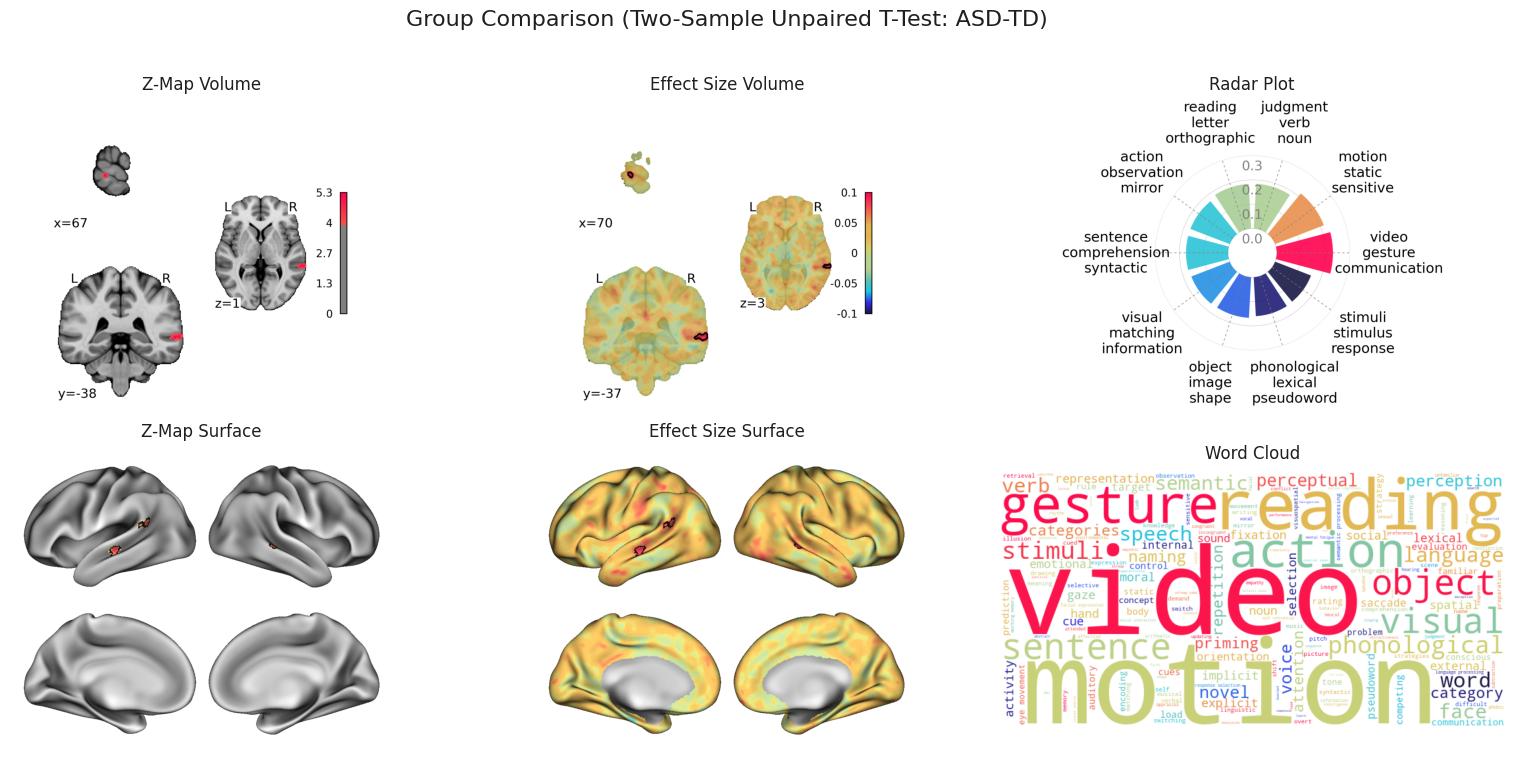

Saved combined figure: ./dset/derivatives/hb-conn/group-atlas/habenula/averaged/combined_1s.png


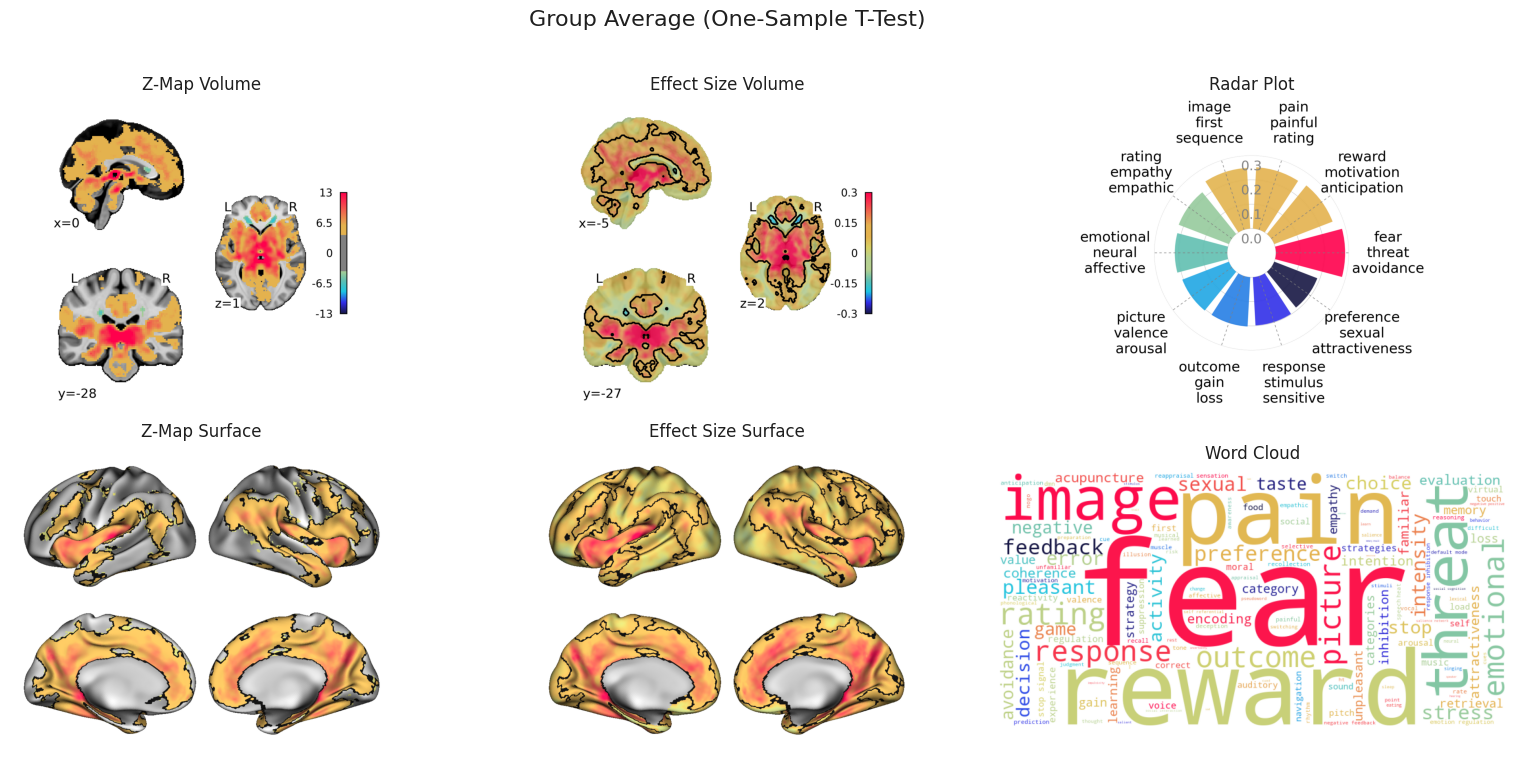

Saved combined figure: ./dset/derivatives/hb-conn/group-atlas/habenula/difference/combined_2s.png


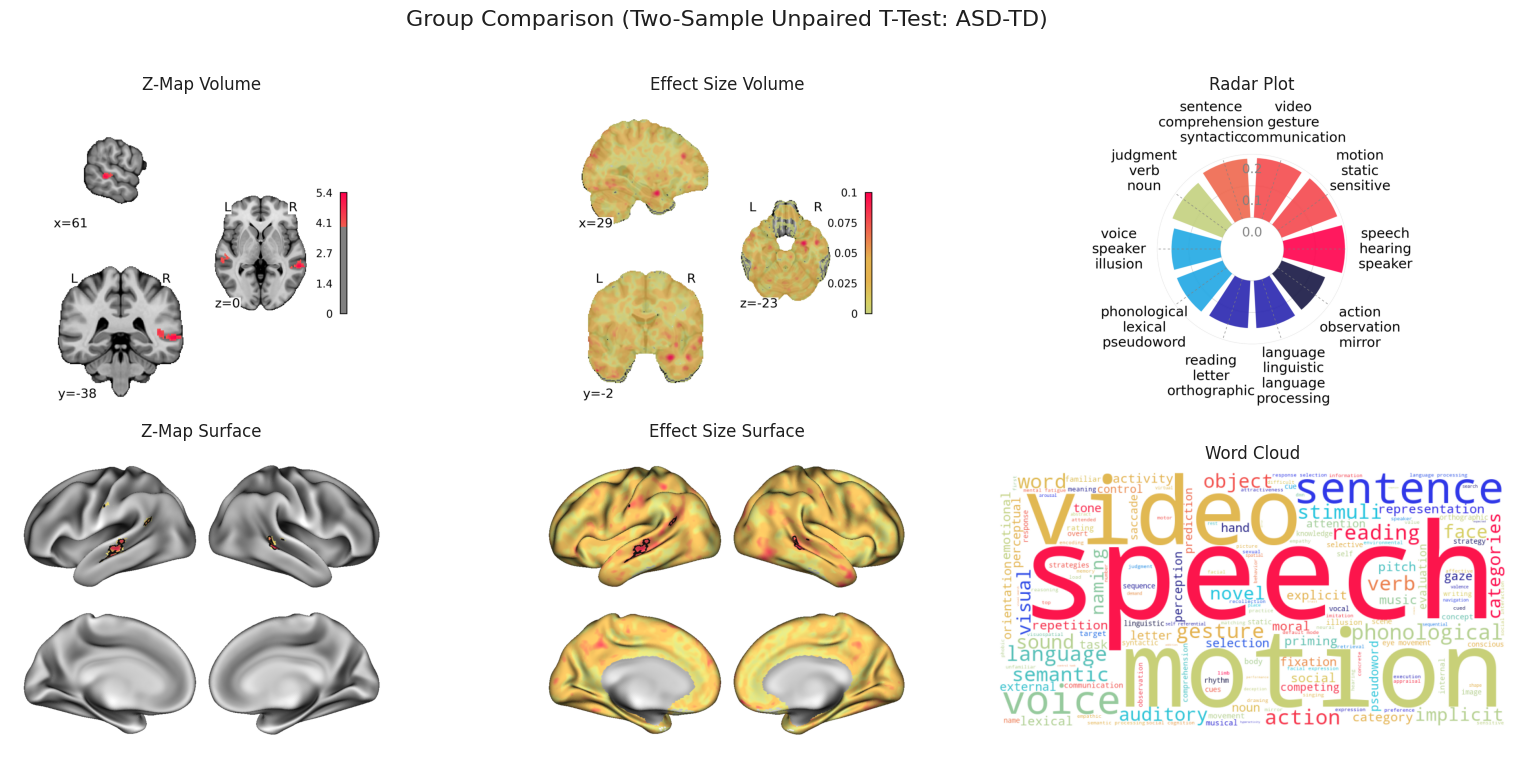

In [11]:
for group_dir in group_dirs:
    group_avg_dir = op.join(group_dir, "averaged")
    group_diff_dir = op.join(group_dir, "difference")

    for test in tests:
        # Determine the correct directory for this test
        if test == "1s":
            fig_source_dir = group_avg_dir
        elif test == "2s":
            fig_source_dir = group_diff_dir
        
        output_file = op.join(fig_source_dir, f"combined_{test}.png")

        figure1 = plt.figure(figsize=(16, 8))
        gs = GridSpec(
            nrows=2, ncols=3, figure=figure1, 
            width_ratios=[1, 1, 1], height_ratios=[1, 1]
        )

        # Column 0: Z-Map volume and surface
        vol_fn = op.join(fig_source_dir, f"{test}_volume.png")
        surf_fn = op.join(fig_source_dir, f"{test}_surface.png")
        
        if os.path.exists(vol_fn):
            img = mpimg.imread(vol_fn)
            ax = figure1.add_subplot(gs[0, 0])
            ax.imshow(img)
            ax.set_title("Z-Map Volume", fontsize=12)
            ax.set_axis_off()
        
        if os.path.exists(surf_fn):
            img = mpimg.imread(surf_fn)
            ax = figure1.add_subplot(gs[1, 0])
            ax.imshow(img)
            ax.set_title("Z-Map Surface", fontsize=12)
            ax.set_axis_off()

        # Column 1: Cohen's d volume and surface
        cohen_vol_fn = op.join(fig_source_dir, f"{test}_volume-cohen.png")
        cohen_surf_fn = op.join(fig_source_dir, f"{test}_surface-cohen.png")
        
        if os.path.exists(cohen_vol_fn):
            img = mpimg.imread(cohen_vol_fn)
            ax = figure1.add_subplot(gs[0, 1])
            ax.imshow(img)
            ax.set_title("Effect Size Volume", fontsize=12)
            ax.set_axis_off()
        
        if os.path.exists(cohen_surf_fn):
            img = mpimg.imread(cohen_surf_fn)
            ax = figure1.add_subplot(gs[1, 1])
            ax.imshow(img)
            ax.set_title("Effect Size Surface", fontsize=12)
            ax.set_axis_off()

        # Column 2: Radar plot and word cloud
        radar_fn = op.join(fig_source_dir, f"{test}_radar.png")
        if os.path.exists(radar_fn):
            radar_img = mpimg.imread(radar_fn)
            ax = figure1.add_subplot(gs[0, 2])
            ax.imshow(radar_img)
            ax.set_title("Radar Plot", fontsize=12)
            ax.set_axis_off()
        else:
            print(f"Warning: Radar plot not found: {radar_fn}")

        # Word cloud in column 2, row 1
        dec_fn = op.join(fig_source_dir, f"{test}_wordcloud.png")
        if os.path.exists(dec_fn):
            img = mpimg.imread(dec_fn)
            ax = figure1.add_subplot(gs[1, 2])
            ax.imshow(img)
            ax.set_title("Word Cloud", fontsize=12)
            ax.set_axis_off()
        else:
            print(f"Warning: Word cloud not found: {dec_fn}")

        figure1.suptitle(test_dict[test], fontsize=16, y=0.95)
        figure1.tight_layout(rect=[0, 0, 1, 0.93])
        figure1.savefig(output_file, bbox_inches="tight", dpi=300)
        print(f"Saved combined figure: {output_file}")
        plt.show()
        plt.close(figure1)

In [12]:
### FIX (see chat): nii_1s_fn/nii_2s_fn used to be named with the same
### "-a{alpha}-p{pthr}_thresh" suffix as thresh_fn below, so on any rerun
### with the same alpha/pthr this cell loaded its OWN previous thresholded
### output and re-thresholded/re-clustered it. Now they point at the plain,
### never-thresholded stat maps, so re-running always starts from raw data.

# Setup directories and file paths
group_drawn_dir = op.join(deriv_dir, "hb-conn/group-drawn/habenula")
group_atlas_dir = op.join(deriv_dir, "hb-conn/group-atlas/habenula")

group_dirs = [group_drawn_dir, group_atlas_dir]

for group_dir in group_dirs:
    group_avg_dir = op.join(group_dir, "averaged")
    group_diff_dir = op.join(group_dir, "difference")

    makedirs(group_avg_dir, exist_ok=True)
    makedirs(group_diff_dir, exist_ok=True)

    # File paths
    brik_fn = op.join(
        group_dir, "sub-group_task-rest_desc-1S2StTesthabenula_briks+tlrc.BRIK"
    )
    table_fn = op.join(group_dir, "sub-group_task-rest_desc-1S2StTesthabenula_table.txt")
    cluster_fn = op.join(
        group_dir, "clustsim", "clustsim_out.NN2_2sided.1D"
    )
    nii_1s_fn = op.join(
        group_avg_dir, "sub-group_task-rest_desc-1SampletTest.nii.gz"
    )
    nii_2s_fn = op.join(
        group_diff_dir, "sub-group_task-rest_desc-2SampletTest.nii.gz"
    )

    # Load cluster correction table
    column_names = [".10000", ".05000", ".02000", ".01000"]
    cluster_df = pd.read_table(cluster_fn, skiprows=8, delim_whitespace=True, names=column_names)
    cluster_df = cluster_df.reset_index()
    cluster_df.rename(columns={'index': 'pthr'}, inplace=True)
    print("Cluster correction table:")
    print(cluster_df)

    # Analysis parameters
    brik_idx = [8, 10]
    nii_fns = [nii_1s_fn, nii_2s_fn]
    tests = ["1s", "2s"]
    alpha = ".01000"
    pthrs = [0.0001, 0.0001]
    cohen_thresh = 0

    # Load participant data for effect size calculations
    data_df = pd.read_csv(table_fn, sep="\t")
    n_sub = data_df.groupby("group").size().sum()
    n_sub_1, n_sub_2 = data_df.groupby("group").size().values
    print(f"Total subjects: {n_sub}, Group sizes: {n_sub_1}, {n_sub_2}")

    # Process each test type (1-sample and 2-sample)
    for brik_i, nii_fn, test, pthr in zip(brik_idx, nii_fns, tests, pthrs):
        print(f"\n=== Processing {test_dict[test]} ===")
        
        # Check if the output file already exists
        if not os.path.exists(nii_fn):
            # determine which group we're processing by the parent directory name
            parent_base = op.basename(op.dirname(group_dir))
            if parent_base == "group-drawn":
                print(f"Creating {nii_fn} from drawn group...")
                convert = f"3dAFNItoNIFTI -prefix {nii_fn} {brik_fn}[{brik_i}]"
                os.system(convert)
            elif parent_base == "group-atlas":
                print(f"Creating {nii_fn} for group-atlas...")
                if test == "1s":
                    convert = f"3dAFNItoNIFTI -prefix {nii_fn} {brik_fn}[{brik_i}]"
                    os.system(convert)
                elif test == "2s":
                    # create an absolute-valued difference map on disk
                    convert = f"3dcalc -a {brik_fn}'[{brik_i}]' -expr 'abs(a)' -prefix {nii_fn}"
                    os.system(convert)
            else:
                raise RuntimeError(f"Unexpected group directory parent: {parent_base}")
        else:
            print(f"File {nii_fn} already exists, skipping conversion.")
        
        # Load and threshold images
        nii_img = nib.load(nii_fn)

        # For two-sample (group-difference) maps, ensure values are positive
        # by taking the absolute value if necessary. This is a safety net
        # but the on-disk nifti should already be absolute from the 3dcalc above.
        if test == "2s":
            try:
                nii_arr_raw = masker.transform(nii_img)
                if np.nanmax(nii_arr_raw) <= 0:
                    # all non-positive -> take absolute
                    nii_arr_pos = np.abs(nii_arr_raw)
                    nii_img = masker.inverse_transform(nii_arr_pos)
            except Exception:
                img = nib.load(nii_fn)
                data = img.get_fdata()
                if np.nanmax(data) <= 0:
                    img_pos = nib.Nifti1Image(np.abs(data), img.affine, img.header)
                    nii_img = img_pos

        z_thresh = p_to_z(pthr)
        clust_ext = cluster_df.loc[cluster_df["pthr"] == pthr, alpha].values[0]
        nii_thr_img = threshold_img(nii_img, z_thresh, cluster_threshold=clust_ext)
        print(f"Cluster extent: {clust_ext}, p-threshold: {pthr}, z-threshold: {z_thresh}")
        
        # Calculate effect sizes (Cohen's d)
        nii_arr = masker.transform(nii_img)
        if test == "1s":
            nii_cohen_arr = nii_arr / np.sqrt(n_sub)
        elif test == "2s":
            nii_cohen_arr = nii_arr / (np.sqrt(n_sub_1) + np.sqrt(n_sub_2))
        
        nii_cohen_img = masker.inverse_transform(nii_cohen_arr)
        
        # Create contour masks for visualization
        nii_thr_arr = masker.transform(nii_thr_img)
        
        # Set visualization parameters
        vmax = round(np.max(np.abs(nii_thr_arr)), 2)
        vmax = 13 if vmax > 13 else vmax
        c_vmax = 0.1 if test == "2s" else 0.3
        
        # Generate cluster table and save thresholded images
        clusters = get_clusters_table(
            nii_thr_img, z_thresh, two_sided=True
        )
        print("Significant clusters:")
        print(clusters)
        
        # Save thresholded images to appropriate directories
        if test == "1s":
            thresh_fn = op.join(group_avg_dir, f"sub-group_task-rest_desc-1SampletTest-a{alpha}-p{pthr}_thresh.nii.gz")
        elif test == "2s":
            thresh_fn = op.join(group_diff_dir, f"sub-group_task-rest_desc-2SampletTest-a{alpha}-p{pthr}_thresh.nii.gz")
        
        nib.save(nii_thr_img, thresh_fn)
        print(f"Saved thresholded nifti: {thresh_fn}")

/var/folders/x1/rzvtxb3x273_5fvyk8ftl70r0000gn/T/ipykernel_48547/3910804737.py:37: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  cluster_df = pd.read_table(cluster_fn, skiprows=8, delim_whitespace=True, names=column_names)


Cluster correction table:
     pthr  .10000  .05000  .02000  .01000
0  0.0500  1457.0  1766.0  2186.0  2473.5
1  0.0200   505.9   615.3   757.0   870.0
2  0.0100   276.9   335.6   416.5   479.0
3  0.0050   164.7   200.0   250.0   293.0
4  0.0020    91.1   111.7   139.7   163.0
5  0.0010    61.3    75.5    93.8   111.4
6  0.0005    42.4    51.9    66.3    77.8
7  0.0002    26.5    33.0    43.7    50.5
8  0.0001    18.7    23.9    31.4    37.5
Total subjects: 1480, Group sizes: 661, 819

=== Processing Group Average (One-Sample T-Test) ===
File ./dset/derivatives/hb-conn/group-drawn/habenula/averaged/sub-group_task-rest_desc-1SampletTest.nii.gz already exists, skipping conversion.
Cluster extent: 37.5, p-threshold: 0.0001, z-threshold: 3.890591886413094


/Users/chloehampson/Desktop/habenula-comparison/.venv/lib/python3.9/site-packages/nilearn/maskers/nifti_masker.py:108: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(
/Users/chloehampson/Desktop/habenula-comparison/.venv/lib/python3.9/site-packages/nilearn/maskers/nifti_masker.py:108: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(


Significant clusters:
   Cluster ID     X     Y     Z  Peak Stat Cluster Size (mm3)
0           1   3.5 -24.5   3.5  28.048861             480872
1          1a   3.5  -0.5   3.5  15.181170                   
2          1b  15.5 -30.5  -4.5  13.453623                   
3          1c   5.5   7.5  -0.5  12.664586                   
4           2 -22.5  -0.5  69.5   6.631356               1728
5          2a -14.5  -0.5  71.5   4.605451                   
6           3 -40.5  33.5  11.5   6.021825               3192
7          3a -38.5  19.5  23.5   5.315705                   
8          3b -46.5  23.5  19.5   5.018819                   
9          3c -46.5  21.5  29.5   4.779835                   
10          4  43.5 -14.5 -28.5   5.956895                488
11          5 -32.5 -56.5  45.5   5.669044               1144
12         5a -26.5 -64.5  41.5   4.614406                   
13          6  37.5 -18.5  39.5   5.620476               1048
14         6a  49.5 -14.5  45.5   5.378482      

/Users/chloehampson/Desktop/habenula-comparison/.venv/lib/python3.9/site-packages/nilearn/maskers/nifti_masker.py:108: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(


...

/Users/chloehampson/Desktop/habenula-comparison/.venv/lib/python3.9/site-packages/nilearn/maskers/nifti_masker.py:108: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(


Cluster extent: 38.6, p-threshold: 0.0001, z-threshold: 3.890591886413094


/Users/chloehampson/Desktop/habenula-comparison/.venv/lib/python3.9/site-packages/nilearn/maskers/nifti_masker.py:108: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(
/Users/chloehampson/Desktop/habenula-comparison/.venv/lib/python3.9/site-packages/nilearn/maskers/nifti_masker.py:108: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(


Significant clusters:
  Cluster ID     X     Y     Z  Peak Stat Cluster Size (mm3)
0          1  63.5 -38.5  -0.5   5.405111                816
1         1a  59.5 -30.5   5.5   4.043229                   
2          2 -54.5 -20.5  -6.5   5.140213               1640
3         2a -60.5 -28.5   3.5   4.647803                   
4         2b -56.5  -8.5 -12.5   4.571720                   
5         2c -60.5 -30.5  -4.5   4.434737                   
6          3  47.5 -40.5   3.5   4.957223                424
7          4 -62.5 -14.5  41.5   4.905821                312
8          5 -56.5 -56.5  21.5   4.551557                376
Saved thresholded nifti: ./dset/derivatives/hb-conn/group-atlas/habenula/difference/sub-group_task-rest_desc-2SampletTest-a.01000-p0.0001_thresh.nii.gz


/Users/chloehampson/Desktop/habenula-comparison/.venv/lib/python3.9/site-packages/nilearn/reporting/_get_clusters_table.py:339: UserWarning: Attention: No clusters with stat lower than -3.890591886413094
  warnings.warn(
